In [ ]:
!pip install --upgrade cvnn
!pip install --upgrade tf-keras

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for cvnn: filename=cvnn-2.0-py2.py3-none-any.whl size=47610 sha256=10b2b91035d75fbfe82bb4bf637ba1a9778ad4ee62ff29c3790079d9daaf6002
  Stored in directory: /root/.cache/pip/wheels/96/5b/85/dbfd5c1f8248d22343620491e55b1b19f7337b0763088a948f
Successfully built cvnn
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 644.9/644.9 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 61.2 MB/s eta 0:00:00
  Attempting uninstall: ml-dtypes
    Found existing installation: ml-dtypes 0.4.1
    Uninstalling ml-dtypes-0.4.1:
      Successfully uninstalled ml-dtypes-0.4.1
  Attempting uninstall: tensorboard
    Found existing installation: tensorboard 2.18.0
    Uninstalling tensorboard-2.18.0:


In [ ]:
import h5py
import numpy as np
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2, fftshift
from matplotlib import colors
import matplotlib.cm as cm

Константы для данной модели

In [ ]:
lam = 0.75e-3
material_refractive_index = 1.7227
air_refractive_index = 1.0003
delta_n = material_refractive_index - air_refractive_index
pixel_size = 100e-6  # Размер пикселя (м)
z_distance = 3e-2

Посмотрим струтуру файла и загрузим веса

In [ ]:
def inspect_h5_file(filepath):
    with h5py.File(filepath, 'r') as f:
        print("Структура файла:")
        f.visititems(lambda name, obj: print(f"{name}: {type(obj)}"))

inspect_h5_file('./D2NN_phase_only_FPMI_.weights.h5')

Структура файла:
layers: <class 'h5py._hl.group.Group'>
layers/complex_input: <class 'h5py._hl.group.Group'>
layers/complex_input/vars: <class 'h5py._hl.group.Group'>
layers/detector: <class 'h5py._hl.group.Group'>
layers/detector/vars: <class 'h5py._hl.group.Group'>
layers/diffraction__layer: <class 'h5py._hl.group.Group'>
layers/diffraction__layer/vars: <class 'h5py._hl.group.Group'>
layers/diffraction__layer/vars/0: <class 'h5py._hl.dataset.Dataset'>
layers/diffraction__layer_1: <class 'h5py._hl.group.Group'>
layers/diffraction__layer_1/vars: <class 'h5py._hl.group.Group'>
layers/diffraction__layer_1/vars/0: <class 'h5py._hl.dataset.Dataset'>
layers/diffraction__layer_2: <class 'h5py._hl.group.Group'>
layers/diffraction__layer_2/vars: <class 'h5py._hl.group.Group'>
layers/diffraction__layer_2/vars/0: <class 'h5py._hl.dataset.Dataset'>
layers/diffraction__layer_3: <class 'h5py._hl.group.Group'>
layers/diffraction__layer_3/vars: <class 'h5py._hl.group.Group'>
layers/diffraction__layer

In [ ]:
def load_d2nn_weights(filepath):
    """Загружает веса всех дифракционных слоёв из HDF5-файла."""
    weights = []
    with h5py.File(filepath, 'r') as f:
        # Ищем все дифракционные слои (diffraction__layer_*)
        for layer_name in f['layers']:
            if layer_name.startswith('diffraction__layer'):
                layer_group = f[f'layers/{layer_name}/vars']
                weight = layer_group['0'][:]  # Основные веса хранятся в dataset '0'
                weights.append(weight)
    return weights

# Пример использования
filepath = './D2NN_phase_only_FPMI_.weights.h5'
all_weights = load_d2nn_weights(filepath)

# Проверка
print(f"Загружено слоёв: {len(all_weights)}")
for i, w in enumerate(all_weights):
    print(f"Слой {i}: форма {w.shape}, мин/макс фаза: {np.min(w):.4f}/{np.max(w):.4f}")

Загружено слоёв: 5
Слой 0: форма (120, 120), мин/макс фаза: 0.0002/6.2832
Слой 1: форма (120, 120), мин/макс фаза: 0.0003/6.2831
Слой 2: форма (120, 120), мин/макс фаза: 0.0000/6.2830
Слой 3: форма (120, 120), мин/макс фаза: 0.0002/6.2827
Слой 4: форма (120, 120), мин/макс фаза: 0.0003/6.2825


Рассчитаем высоту каждого нейрона из сдвига фазы, считая что коэффициент преломления одинаковый у всех пластинок(VeroBlackPlus RGD875, refractive index: 1.7227)

In [ ]:
delta_n = material_refractive_index - air_refractive_index

height_map = (lam*np.array(all_weights)) / (2*np.pi*delta_n)

print("Форма карты высот для всех слоёв:", end=' ')
print(np.shape(np.array(height_map)))
print("Максимальное и минимальное значение в height_map: " + str(np.max(height_map)) + ", "+ str(np.min(height_map)) + "\n")

np.save('height_map_FPMI.npy', np.array(height_map))
print("Файл height_map.npy успешно сохранён")

Форма карты высот для всех слоёв: (5, 120, 120)
Максимальное и минимальное значение в height_map: 0.0010382027, 1.9584032e-09

Файл height_map.npy успешно сохранён


Провизуалищируем слои с учетом высоты нейронов

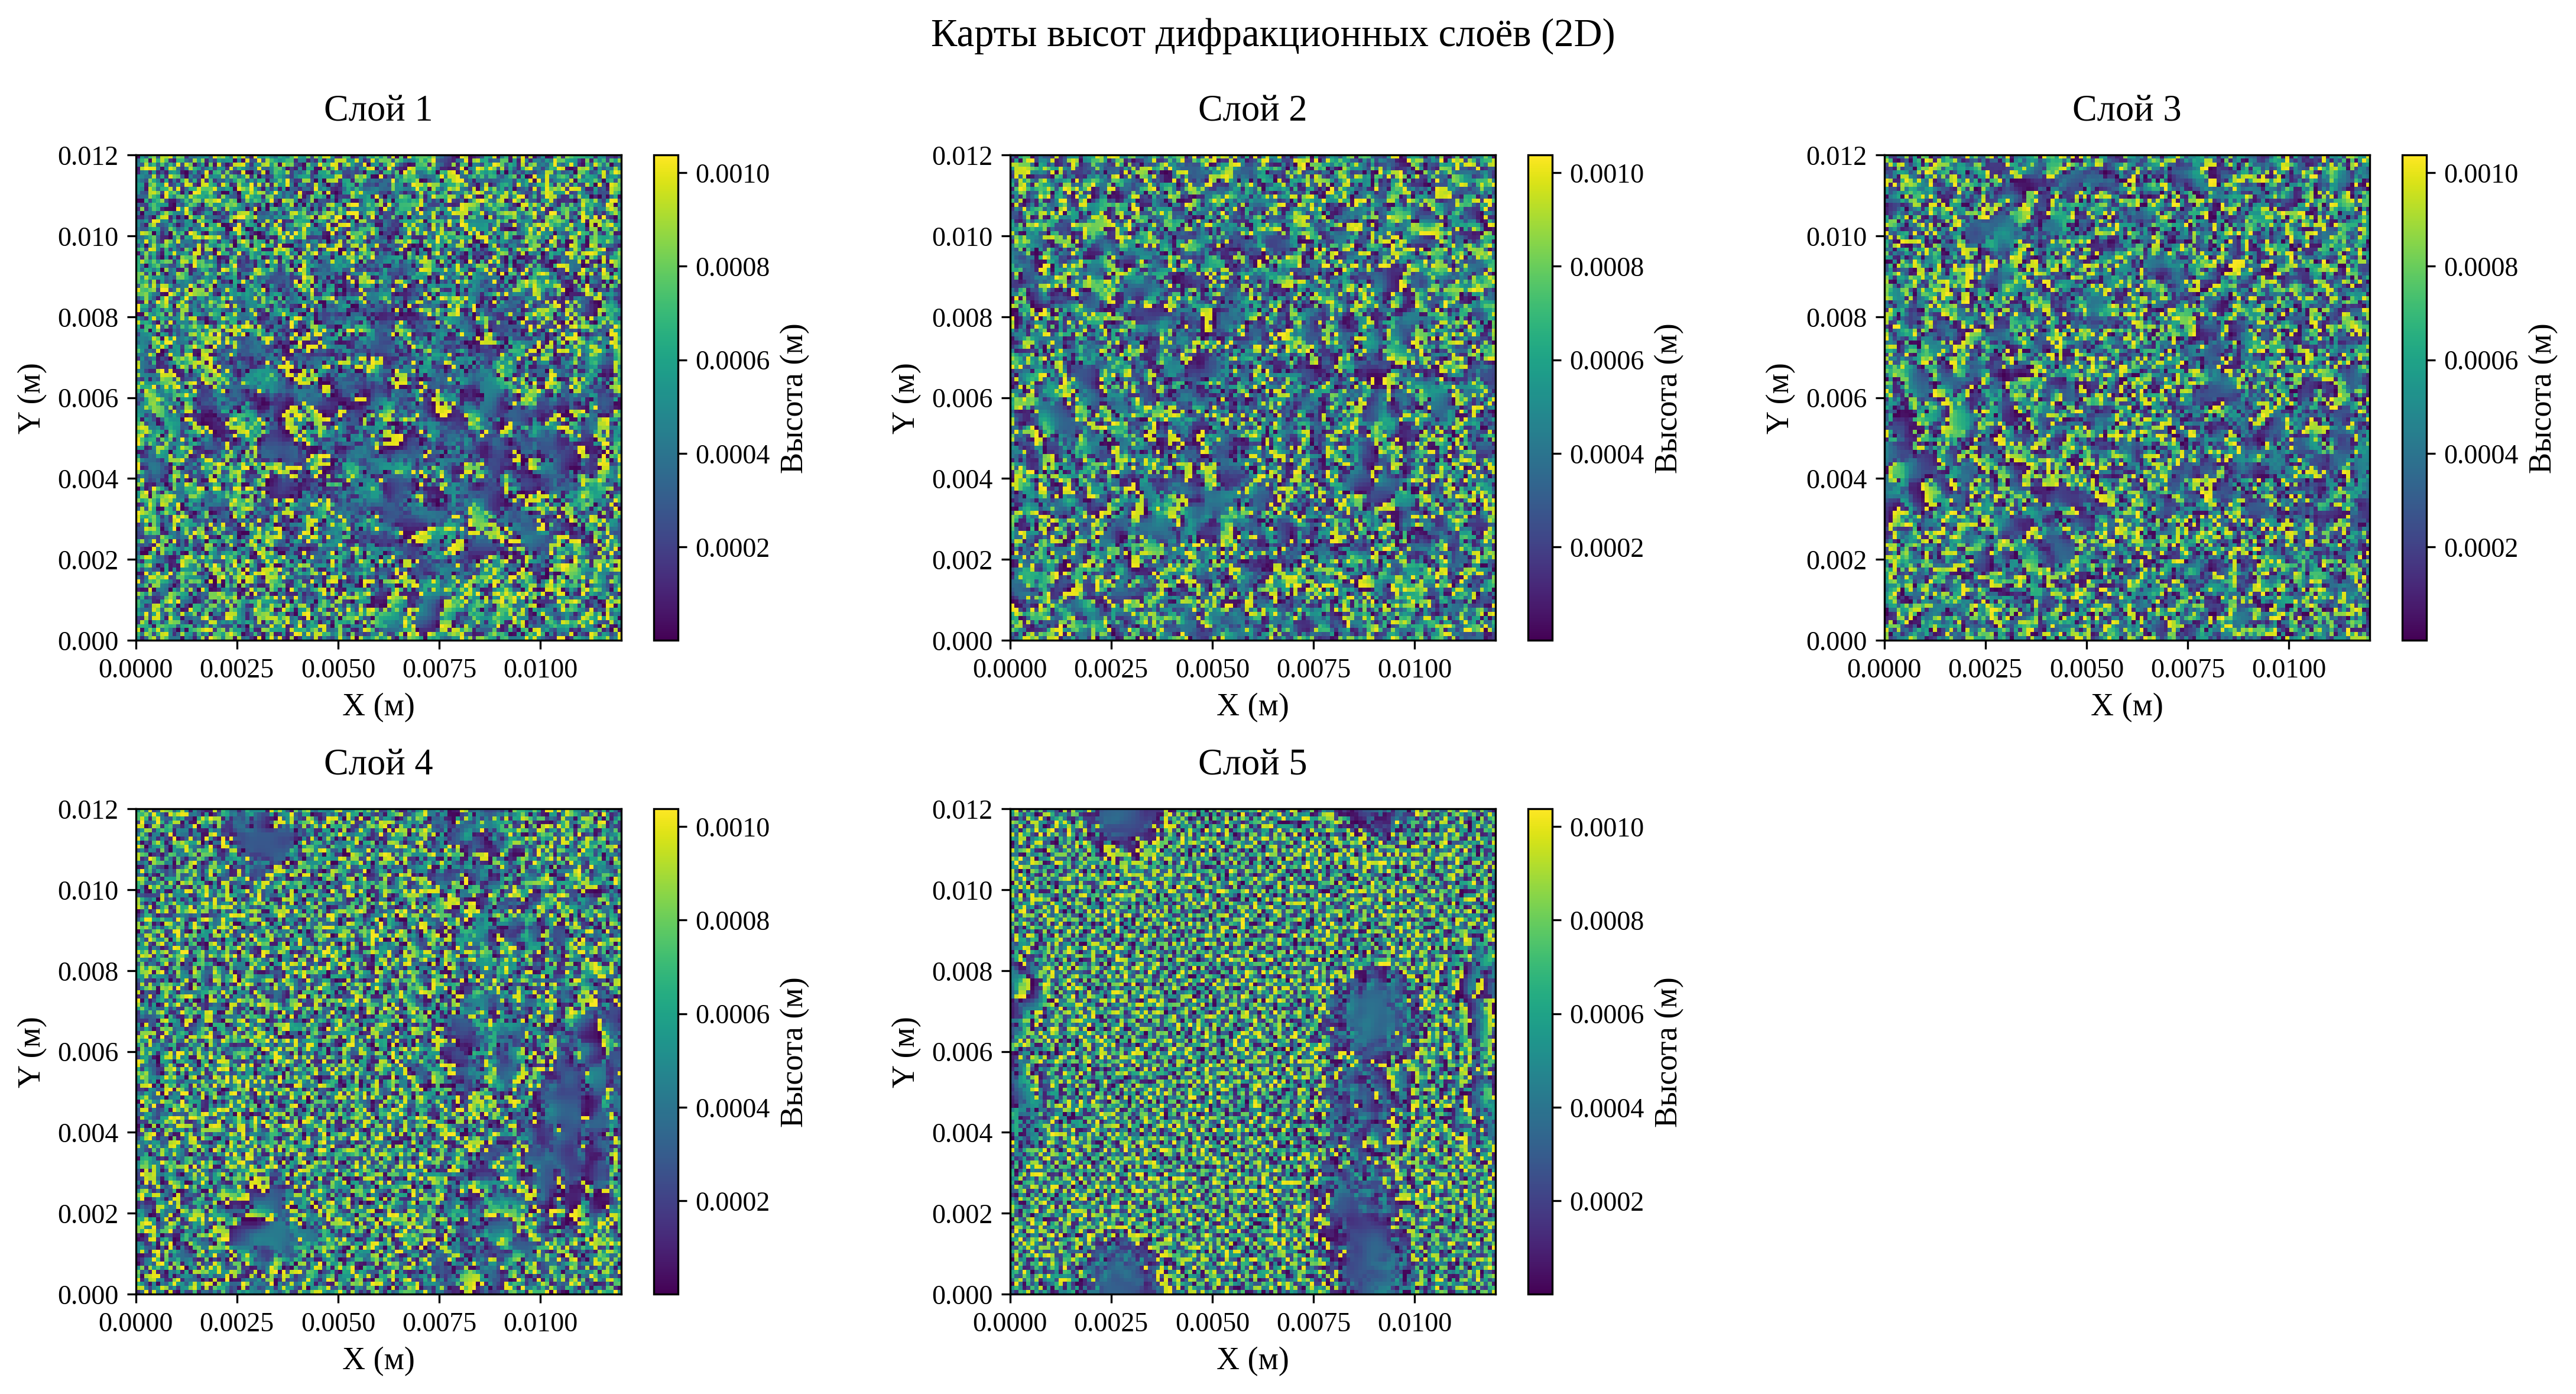

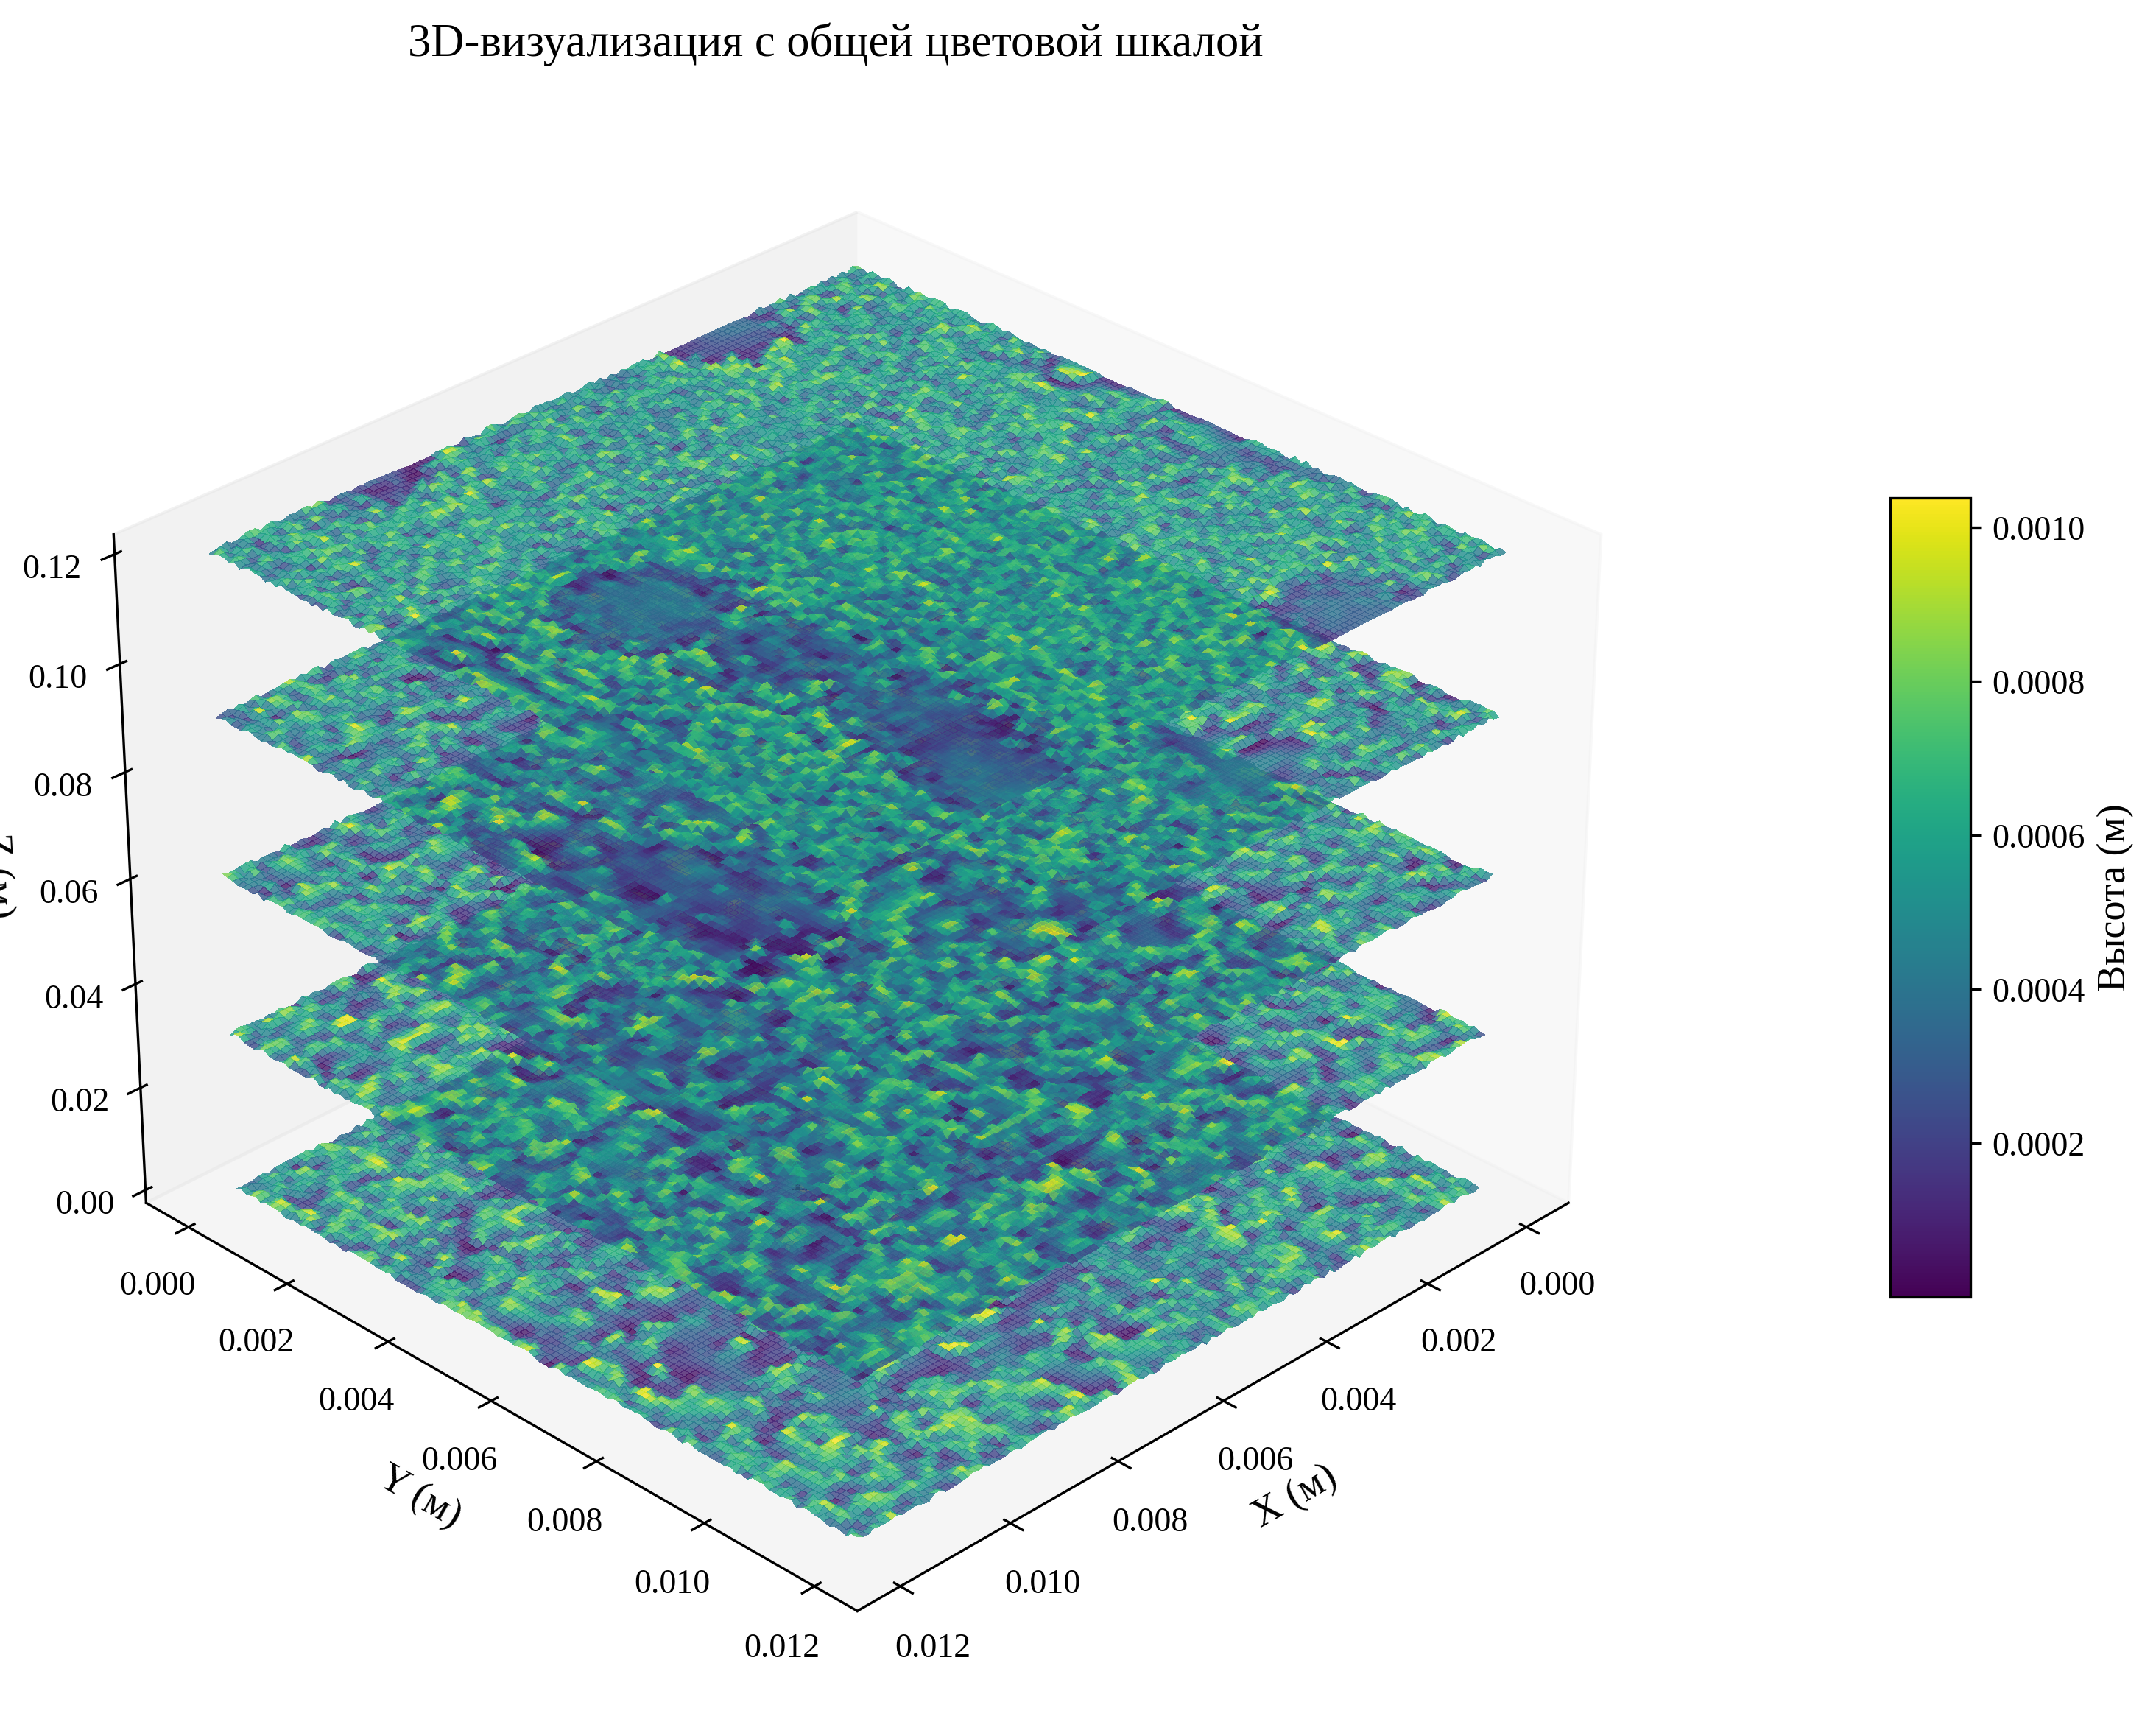

In [ ]:

# параметры вашего height_map и z_distance
height_map = np.load('height_map_FPMI.npy')  # shape = (num_layers, size, size)
num_layers, size, _ = height_map.shape
# 1. 2D визуализация
plt.figure(figsize=(15, 8))
for i in range(num_layers):
    plt.subplot(2, 3, i+1)
    plt.imshow(height_map[i], cmap='viridis', extent=[0, size*pixel_size, 0, size*pixel_size])
    plt.colorbar(label='Высота (м)')
    plt.title(f'Слой {i+1}')
    plt.xlabel('X (м)')
    plt.ylabel('Y (м)')
plt.suptitle('Карты высот дифракционных слоёв (2D)', fontsize=16)
plt.tight_layout()
plt.show()


# 1) вычисляем общие min/max по всем слоям
h_min, h_max = height_map.min(), height_map.max()
norm = colors.Normalize(vmin=h_min, vmax=h_max)
cmap = cm.get_cmap('viridis')

# 2) готовим сетку X, Y
x = np.linspace(0, (size-1)*pixel_size, size)
y = np.linspace(0, (size-1)*pixel_size, size)
X, Y = np.meshgrid(x, y)

# 3) создаём 3D-фигуру
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# 4) рисуем каждый слой с общим нормированием цвета
for i in range(num_layers):
    Z0 = np.ones_like(X) * (i * z_distance)
    H = height_map[i]
    # facecolors = карта RGB из наших высот, нормированных в [0,1]
    facecolors = cmap(norm(H))
    surf = ax.plot_surface(
        X, Y, Z0 + H,
        cmap='viridis', alpha=0.8,
        rcount=size, ccount=size,
        linewidth=0, antialiased=False, shade=False
    )
    # пометка слоя
    ax.text(np.mean(X), np.mean(Y), i*z_distance,
            f'Layer {i+1}', color='black', ha='center')

# 5) общий цветбар, привязанный к норме
mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
mappable.set_array([])  # достаточно пустого массива
cbar = fig.colorbar(mappable, ax=ax, shrink=0.5, aspect=10, pad=0.1)
cbar.set_label('Высота (м)')

# 6) финальные настройки вида
ax.set_xlabel('X (м)')
ax.set_ylabel('Y (м)')
ax.set_zlabel('Z (м)')
ax.set_title('3D-визуализация с общей цветовой шкалой')
ax.view_init(elev=30, azim=45)
ax.grid(False)
plt.tight_layout()
plt.show()

Теперь запустим изображение в данную систему решеток

In [ ]:
import os
import warnings
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from IPython.display import display
import tensorflow_datasets as tfds
from tensorflow import keras
from keras.datasets import fashion_mnist
tfds.disable_progress_bar()
from tensorflow.keras.models import Model
from tensorflow.keras.losses import Loss
from tensorflow.keras.layers import Layer,Lambda,InputLayer
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.constraints import Constraint
from tensorflow.data.experimental import copy_to_device
warnings.filterwarnings('ignore')

In [ ]:
LAYER_SIZE = 120
BUFFER_SIZE = 1000
BATCH_SIZE = 16
DATASET_NAME = 'emnist/letters'
UP_SAMPLING_SIZE = 56
def preprocess(image, label):
    # Конвертируем лейблы классов
    label = tf.one_hot(tf.cast(label, tf.int32), num_classes)

    # Увеличиваем размер картинки
    padding_size = (LAYER_SIZE - UP_SAMPLING_SIZE)//2
    image = tf.cast(image, tf.float32)

    up_sampling_image = tf.image.resize(image,
                                        size=[UP_SAMPLING_SIZE, UP_SAMPLING_SIZE],
                                        method='nearest')
    up_sampling_image = up_sampling_image / 255.0 / 2.0

    # Создаем фазовый объект
    phase_image = tf.math.exp(2*np.pi*1j*tf.cast(up_sampling_image,dtype=tf.complex64))

    # Паддинг
    zero_padded_image = tf.pad(phase_image,
                                paddings=[[padding_size,padding_size],[padding_size,padding_size],[0,0]],
                                mode="CONSTANT",constant_values=0)

    return tf.cast(zero_padded_image, dtype=tf.complex64), label

In [ ]:
datasets, info = tfds.load(name=DATASET_NAME, with_info=True, as_supervised=True, data_dir='./data')

mnist_train, mnist_test = datasets['train'], datasets['test']

num_train = info.splits['train'].num_examples
num_test = info.splits['test'].num_examples

num_classes = info.features['label'].num_classes
class_names = info.features['label'].names

NUM_CLASSES = num_classes

print(f"Размер тренировочных данных: {num_train}")
print(f"Размер тестовых данных: {num_test}")
print(f"Число классов: {num_classes}")

Dataset emnist downloaded and prepared to data/emnist/letters/3.1.0. Subsequent calls will reuse this data.
Размер тренировочных данных: 88800
Размер тестовых данных: 14800
Число классов: 37


In [ ]:
train_dataset = mnist_train.map(preprocess).cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
test_dataset = mnist_test.map(preprocess).batch(BATCH_SIZE)

print(f"Число батчей в тренировочной выборки: {len(train_dataset)}")
print(f"Число батчей в тестовой выборки: {len(test_dataset)}")

Число батчей в тренировочной выборки: 5550
Число батчей в тестовой выборки: 925


In [ ]:
target_labels = [13, 6, 20, 9, 16, 11, 18, 19, 21, 15, 26, 22]
num_classes = len(target_labels) ## ДЛЯ PREPROCESS
def filter_by_label(image, label):
    return tf.reduce_any(tf.equal(label, target_labels))

filtered_train = mnist_train.filter(filter_by_label)
filtered_test = mnist_test.filter(filter_by_label)

f_train_dataset = filtered_train.map(preprocess).cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE)
f_test_dataset = filtered_test.map(preprocess).batch(BATCH_SIZE)

def get_dataset_length(dataset):
    return sum(1 for _ in dataset)


print(f"Число cтрок тренировочной выборки: {get_dataset_length(filtered_train)}")
print(f"Число строк тестовой выборки: {get_dataset_length(filtered_test)}")

Число cтрок тренировочной выборки: 41015
Число строк тестовой выборки: 6000


In [ ]:
class ClipPhase(Constraint):
    def __init__(self, min_value=0.0, max_value=2* tf.constant(np.pi)):
        self.min_value = min_value
        self.max_value = max_value

    def __call__(self, w):
        return tf.math.floormod(w, 2.0 *  tf.constant(np.pi))

    def get_config(self):
        return {"min_value": self.min_value, "max_value": self.max_value}

In [ ]:
class Diffraction_Layer(Layer):
    def __init__(self, units=120, wavelength=0.75e-3):
        super().__init__()
        self.units = units
        self.Nx = units
        self.dx = tf.constant(100e-6, dtype=tf.float32)
        self.lam = tf.constant(wavelength, dtype=tf.float32)
        self.z = tf.constant(3e-2, dtype=tf.float32)

    def build(self, shape):
        phase_init = tf.random_uniform_initializer(minval=0, maxval=tf.constant(np.pi))
        self.phase = self.add_weight(
            name="phase",
            shape=(self.units, self.units),
            initializer=phase_init,
            trainable=True,
            constraint=ClipPhase()
        )


    def angular_spectrum_propagator(self, E):
        Nx = self.Nx
        dx = self.dx
        lam = self.lam
        z = self.z

        # FFT
        E_fft = tf.signal.fft2d(E)
        E_fft = tf.signal.fftshift(E_fft)

        # Частотная сетка (всё в float32)
        fx = tf.linspace(-0.5 / dx, 0.5 / dx, Nx)
        fxx, fyy = tf.meshgrid(fx, fx)
        fxx = tf.cast(fxx, tf.float32)
        fyy = tf.cast(fyy, tf.float32)

        # k и аргумент
        k = tf.constant(1.0, dtype=tf.float32) / lam
        arg = tf.square(k) - tf.square(fxx) - tf.square(fyy)

        # kz: чисто вещественная и мнимая части
        sqrt_arg = tf.sqrt(tf.abs(arg))
        kz_real = tf.where(arg >= 0.0, sqrt_arg, tf.zeros_like(sqrt_arg))
        kz_imag = tf.where(arg < 0.0, sqrt_arg, tf.zeros_like(sqrt_arg))

        kz = tf.complex(kz_real, kz_imag)
        H = tf.exp(1j * kz * tf.cast(z, tf.complex64))

        # Обратный сдвиг и обратное FFT
        propagated = tf.signal.ifft2d(tf.signal.ifftshift(E_fft * H))

        return propagated

    @tf.function
    def call(self, inputs):
        phase_mod = tf.exp(1j * tf.cast(self.phase, tf.complex64))
        return self.angular_spectrum_propagator(inputs) * phase_mod

In [ ]:
class Propogation(Layer):
    def __init__(self, units=120, wavelength=0.75e-3):
        super(Propogation, self).__init__()
        self.units = units
        self.diff_layer = Diffraction_Layer(units=units, wavelength=wavelength)            # Для свободного пространства

    def build(self, input_shape):
        pass

    @tf.function
    def call(self, inputs):
        return self.diff_layer.angular_spectrum_propagator(inputs)

In [ ]:
class Detector(Layer):
    def __init__(self, num_classes=10, grid_division=None):
        """
        Детектор фазовых признаков для произвольного числа классов
        """
        super(Detector, self).__init__()
        self.num_classes = num_classes

        if grid_division is None:
            self.grid_rows = int(np.ceil(np.sqrt(num_classes)))
            self.grid_cols = int(np.ceil(num_classes / self.grid_rows))
        else:
            self.grid_rows, self.grid_cols = grid_division
            assert self.grid_rows * self.grid_cols >= num_classes, \
                f"Количество блоков ({self.grid_rows*self.grid_cols}) должно быть >= числу классов ({num_classes})"

    def build(self, shape):
      print(f"Детектор инициализирован с числом классов: {num_classes}")
      print(f"Размеры сетки детектора: {self.grid_rows}x{self.grid_cols}")
      pass

    @tf.function
    def call(self, inputs):
        batch_size = tf.shape(inputs)[0]
        H, W = tf.shape(inputs)[1], tf.shape(inputs)[2]

        # Размеры каждого блока
        hh, ww = H // self.grid_rows, W // self.grid_cols

        regions = []
        for i in range(self.grid_rows):
            for j in range(self.grid_cols):
                block = inputs[:, i*hh:(i+1)*hh, j*ww:(j+1)*ww]
                regions.append(tf.reduce_mean(tf.abs(block), axis=[1,2]))

        # Берем только необходимое количество регионов
        regions = regions[:self.num_classes]

        return tf.stack(regions, axis=1)

    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.num_classes)

    def get_config(self):
        config = super().get_config()
        config.update({
            'num_classes': self.num_classes,
            'grid_rows': self.grid_rows,
            'grid_cols': self.grid_cols
        })
        return config

Input shape: (120, 120, 1)


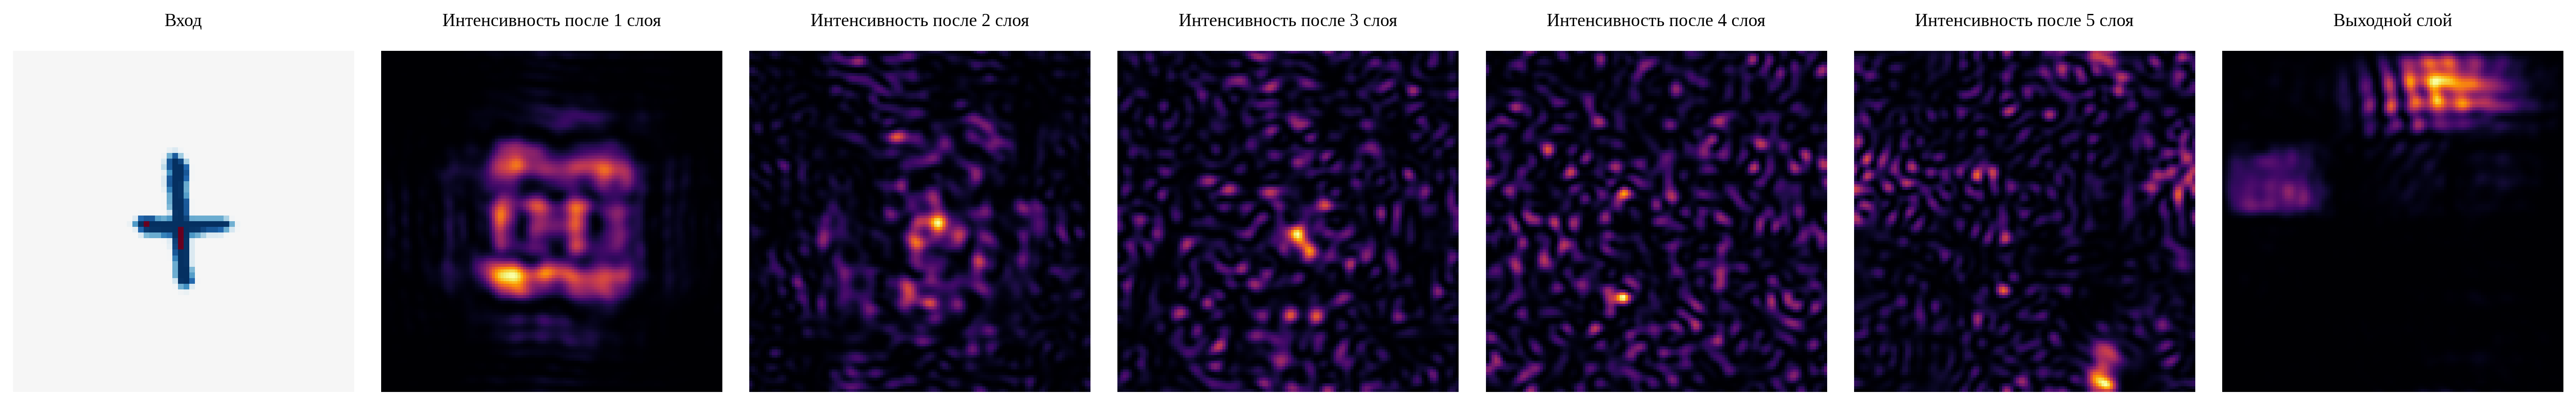

In [ ]:
# === 1) Загрузка весов фазовых слоёв из HDF5 ===
def load_d2nn_weights(filepath):
    weights = []
    with h5py.File(filepath, 'r') as f:
        layer_names = sorted(
            name for name in f['layers'].keys()
            if name.startswith('diffraction__layer')
        )
        for name in layer_names:
            w = f[f'layers/{name}/vars']['0'][:]
            # Convert to float32 explicitly and ensure proper range
            w = w.astype(np.float32)
            weights.append(w)
    return weights

weights = load_d2nn_weights('./D2NN_phase_only_FPMI_.weights.h5')
num_layers, Nx = len(weights), weights[0].shape[0]

# === 2) Подготовка слоёв ===
diff_layers = [Diffraction_Layer(units=Nx) for _ in range(num_layers)]
final_prop = Propogation(units=Nx)

# Инициализация слоёв
dummy = tf.zeros((1, Nx, Nx), dtype=tf.complex64)
for layer in diff_layers:
    layer.build(dummy.shape)

# Установка весов
for i, layer in enumerate(diff_layers):
    phase_map = tf.constant(weights[i], dtype=tf.float32) % (2*np.pi)
    layer.phase.assign(phase_map)

# === 3) Загрузка входных данных ===
for images, _ in f_train_dataset.take(1):
    inp = images[14]
print(f"Input shape: {inp.shape}")

# Подготовка входного поля
E0 = tf.squeeze(inp, axis=-1)
E = tf.expand_dims(E0, axis=0)

# === 4) Пропагация с сохранением результатов ===
intensity_results = []
phase_results = []

# Сохраняем входные данные
phase_results.append(('Input Phase', tf.math.angle(E0)))
intensity_results.append(('Input Intensity', np.abs(E0)**2))

# Проход через слои
for i, layer in enumerate(diff_layers):
    E = layer.call(E)
    E_squeezed = tf.squeeze(E)
    intensity_results.append((f'Layer {i+1} Intensity', np.abs(E_squeezed)**2))
    phase_results.append((f'Layer {i+1} Phase', tf.math.angle(E_squeezed)))

# Финальное распространение
E = final_prop.call(E)
E_out = tf.squeeze(E)
intensity_results.append(('Output Intensity', np.abs(E_out)**2))
phase_results.append(('Output Phase', tf.math.angle(E_out)))
# ... (предыдущий код до визуализации остается без изменений)

# ... (весь предыдущий код остается без изменений до визуализации)

# === 5) Расширенная визуализация с высоким разрешением ===
# Увеличиваем размер фигуры и DPI
fig = plt.figure(figsize=(20, 15), dpi=300)  # Больший размер и высокий DPI

params = {
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Liberation Serif", "DejaVu Serif"],
    "font.size": 14,
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.figsize": (13, 5.5),
    "figure.dpi": 300,
    "lines.linewidth": 2.5,
    "lines.markersize": 8,
    "axes.titlepad": 14
}

plt.rcParams.update(params)
# Входная фаза
plt.subplot(2, num_layers+2, 1)
rotated_input_phase = np.rot90(tf.math.angle(E0).numpy(), k=-1)
flipped_phase = np.fliplr(rotated_input_phase)
plt.imshow(flipped_phase, cmap='RdBu', vmin=-np.pi, vmax=np.pi)
plt.title('Вход', fontsize=10)
plt.axis('off')

# Промежуточные результаты после каждого слоя
E_propagated = tf.expand_dims(E0, axis=0)
intensity_maps = []

for i, layer in enumerate(diff_layers):
    E_propagated = layer.call(E_propagated)
    current_intensity = tf.squeeze(tf.abs(E_propagated)**2)
    intensity_maps.append(current_intensity.numpy())

    plt.subplot(2, num_layers+2, i+2)
    plt.imshow(intensity_maps[-1], cmap='inferno')
    plt.title(f'Интенсивность после {i+1} слоя', fontsize=10)
    plt.axis('off')

# Финальное распространение
E_final = final_prop.call(E_propagated)
I_out = tf.squeeze(tf.abs(E_final)**2).numpy()

# Выходная интенсивность
plt.subplot(2, num_layers+2, num_layers+2)
plt.imshow(I_out, cmap='inferno')
plt.title('Выходной слой', fontsize=10)
plt.axis('off')

# Сохраняем изображение с высоким разрешением перед показом
plt.savefig('high_res_dnn_visualization.png', dpi=300, bbox_inches='tight', pad_inches=0.1)

plt.tight_layout()
plt.show()

Input shape: (120, 120, 1)


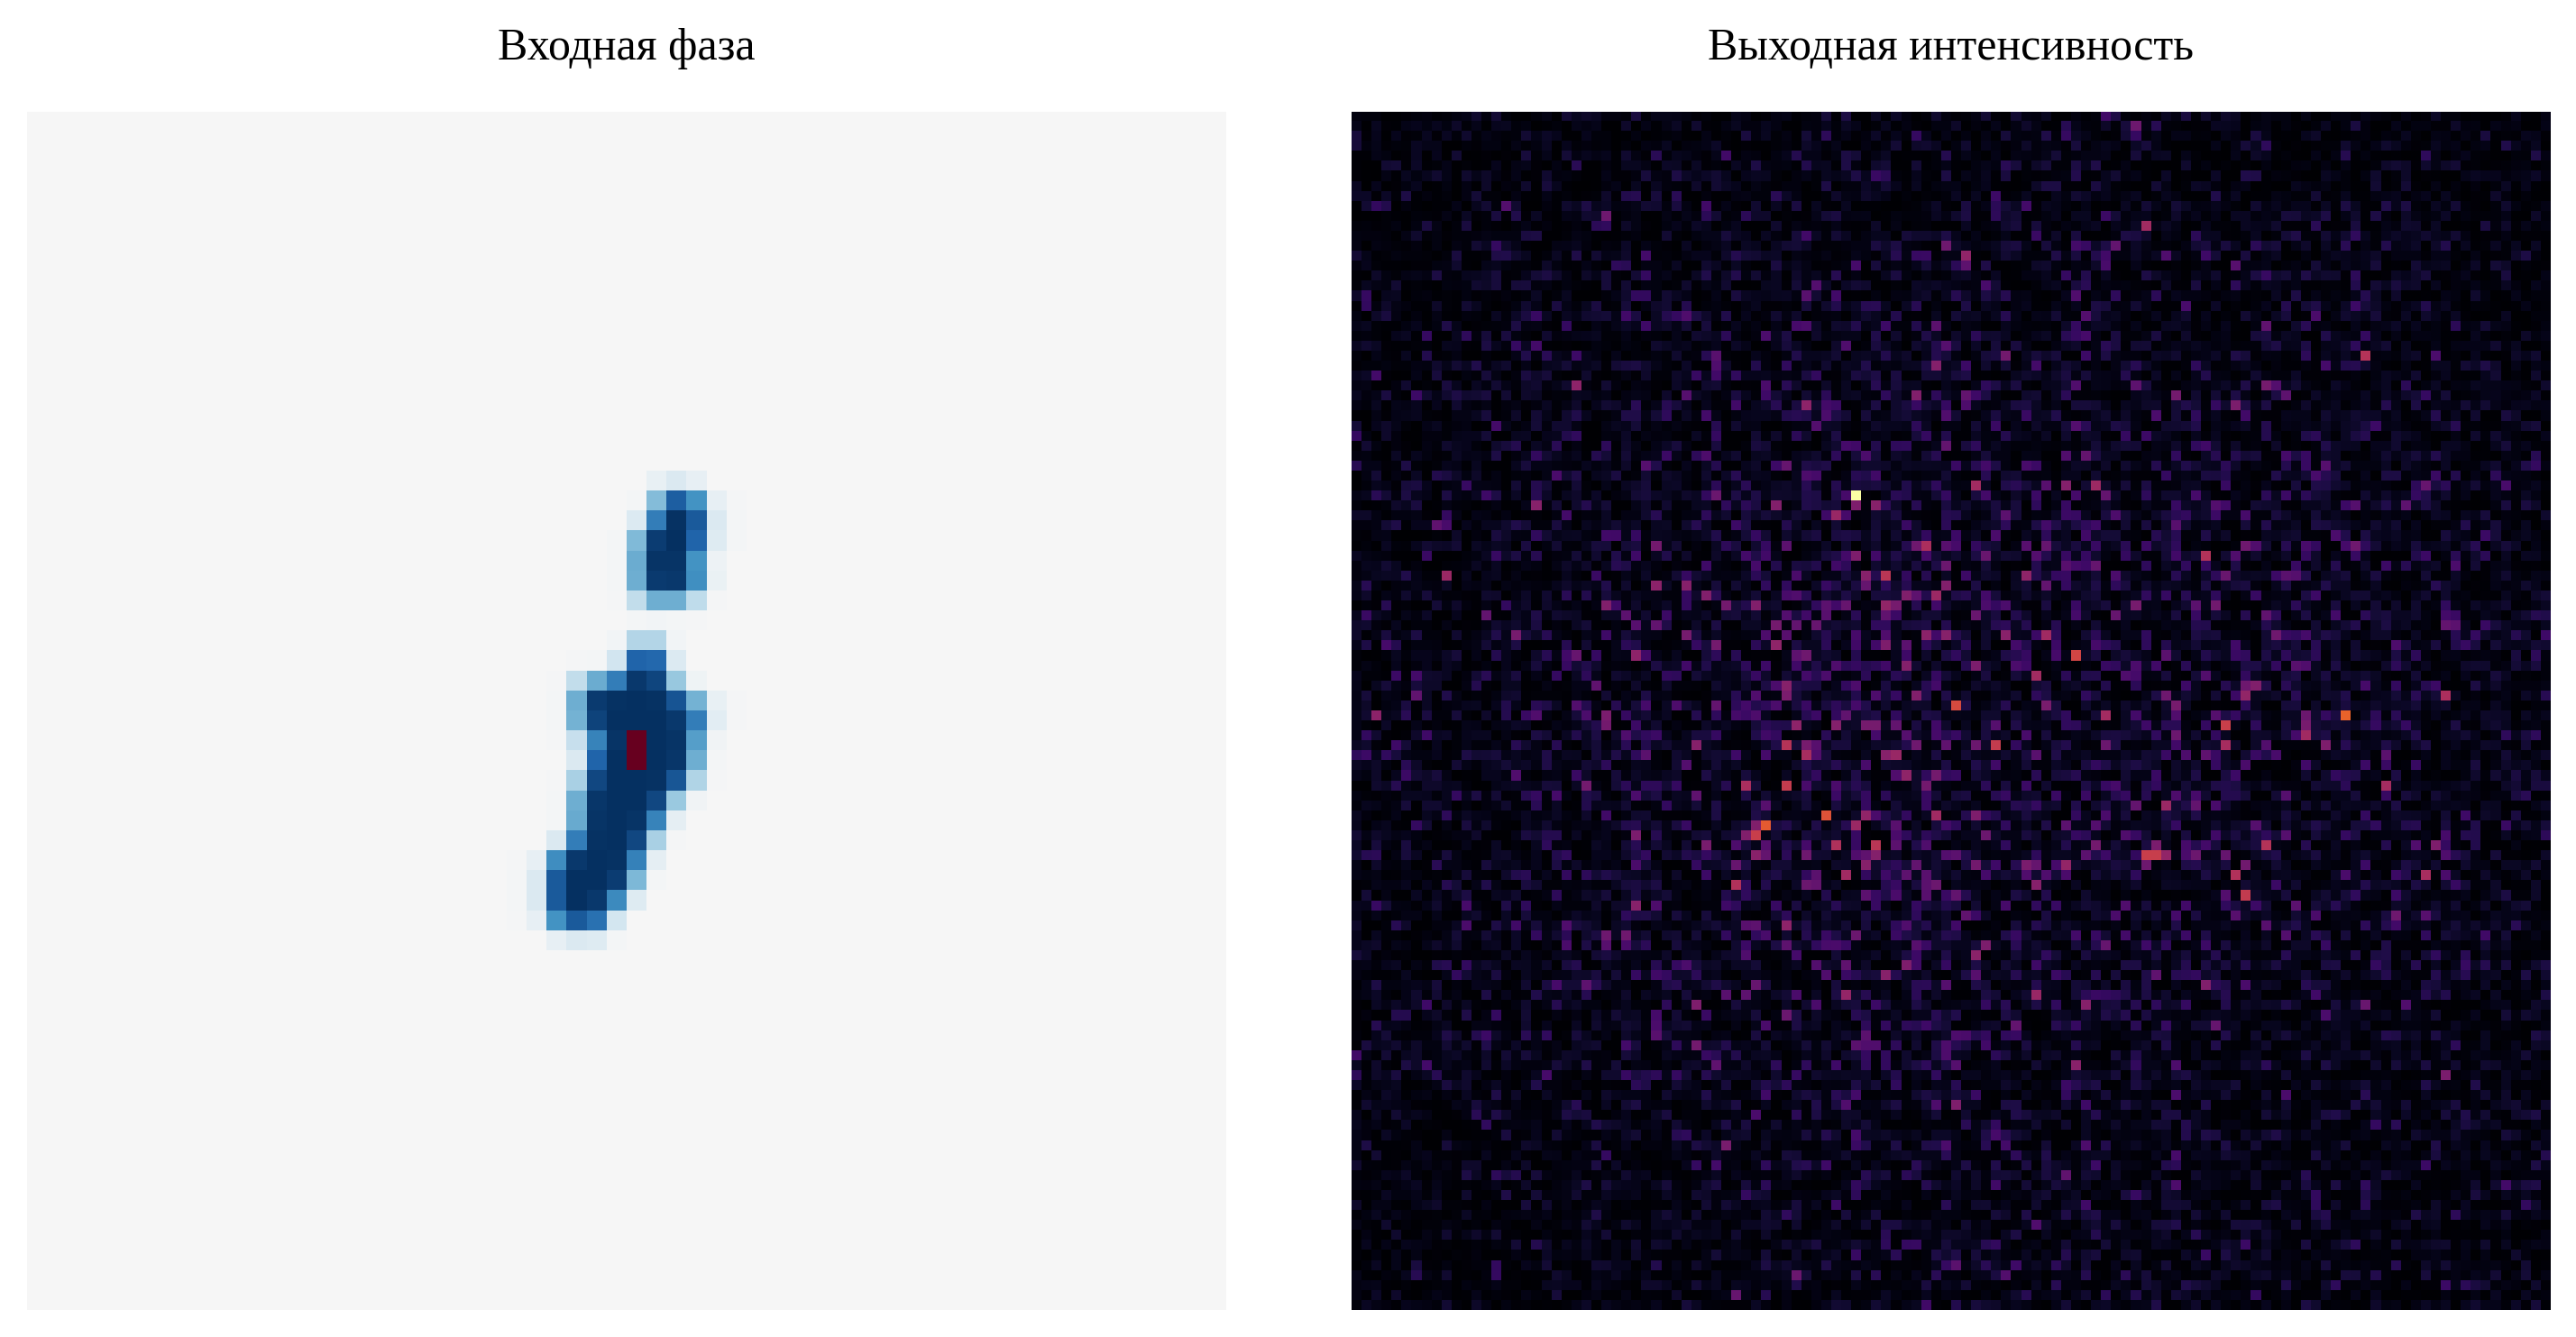

In [ ]:
# === 1) Загрузка весов фазовых слоёв из HDF5 ===
def load_d2nn_weights(filepath):
    weights = []
    with h5py.File(filepath, 'r') as f:
        layer_names = sorted(
            name for name in f['layers'].keys()
            if name.startswith('diffraction__layer')
        )
        for name in layer_names:
            w = f[f'layers/{name}/vars']['0'][:]
            # Convert to float32 explicitly and ensure proper range
            w = w.astype(np.float32)
            weights.append(w)
    return weights

weights = load_d2nn_weights('./D2NN_phase_only_FPMI_.weights.h5')
num_layers, Nx = len(weights), weights[0].shape[0]

# === 2) Подготовка слоёв ===
diff_layers = [Diffraction_Layer(units=Nx, wavelength=0.9e-4) for _ in range(num_layers)]
final_prop = Propogation(units=Nx, wavelength=0.9e-4)

# Инициализация слоёв
dummy = tf.zeros((1, Nx, Nx), dtype=tf.complex64)
for layer in diff_layers:
    layer.build(dummy.shape)

# Установка весов
for i, layer in enumerate(diff_layers):
    phase_map = tf.constant(weights[i], dtype=tf.float32) % (2*np.pi)
    layer.phase.assign(phase_map)

# === 3) Загрузка входных данных ===
for images, _ in f_test_dataset.take(1):
    inp = images[14]
print(f"Input shape: {inp.shape}")

# Подготовка входного поля
E0 = tf.squeeze(inp, axis=-1)
E = tf.expand_dims(E0, axis=0)

# === 4) Пропагация с сохранением результатов ===
intensity_results = []
phase_results = []

# Сохраняем входные данные
phase_results.append(('Input Phase', tf.math.angle(E0)))
intensity_results.append(('Input Intensity', np.abs(E0)**2))

# Проход через слои
for i, layer in enumerate(diff_layers):
    E = layer.call(E)
    E_squeezed = tf.squeeze(E)
    intensity_results.append((f'Layer {i+1} Intensity', np.abs(E_squeezed)**2))
    phase_results.append((f'Layer {i+1} Phase', tf.math.angle(E_squeezed)))

# Финальное распространение
E = final_prop.call(E)
E_out = tf.squeeze(E)
intensity_results.append(('Output Intensity', np.abs(E_out)**2))
phase_results.append(('Output Phase', tf.math.angle(E_out)))

# === 5) Упрощенная визуализация - только первый и последний слой ===
# Увеличиваем размер фигуры и DPI
fig = plt.figure(figsize=(10, 5), dpi=300)  # Оптимизированный размер для двух изображений

params = {
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Liberation Serif", "DejaVu Serif"],
    "font.size": 14,
    "axes.labelsize": 13,
    "axes.titlesize": 15,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 300,
    "lines.linewidth": 2.5,
    "lines.markersize": 8,
    "axes.titlepad": 14
}

plt.rcParams.update(params)

# Входная фаза
plt.subplot(1, 2, 1)
rotated_input_phase = np.rot90(tf.math.angle(E0).numpy(), k=-1)
flipped_phase = np.fliplr(rotated_input_phase)
plt.imshow(flipped_phase, cmap='RdBu', vmin=-np.pi, vmax=np.pi)
plt.title('Входная фаза', fontsize=12)
plt.axis('off')

# Пропагация через все слои
E_propagated = tf.expand_dims(E0, axis=0)
for layer in diff_layers:
    E_propagated = layer.call(E_propagated)

# Финальное распространение
E_final = final_prop.call(E_propagated)
I_out = tf.squeeze(tf.abs(E_final)**2).numpy()

# Выходная интенсивность
plt.subplot(1, 2, 2)
plt.imshow(I_out, cmap='inferno')
plt.title('Выходная интенсивность', fontsize=12)
plt.axis('off')

# Сохраняем изображение с высоким разрешением
plt.savefig('simplified_dnn_visualization.png', dpi=300, bbox_inches='tight', pad_inches=0.1)

plt.tight_layout()
plt.show()